# 01. Data Loading and Exploration

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand the key concepts of this topic
- Apply the topic using Python code examples
- Practice with small, realistic datasets or scenarios

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 08 "Exploring the Data Generation Process" — the same habit of profiling a real dataset before modelling it.

**Used later in:** Course 05 (AIAT 115) — Unit 2, which turns this first look into a full data-cleaning workflow.

---


## 🌍 A real case: the spreadsheet that shaped austerity policy

In 2010 Carmen Reinhart and Kenneth Rogoff published *Growth in a Time of Debt*, reporting that
countries whose public debt passes 90% of GDP average **−0.1%** real GDP growth. The number was
quoted in budget debates on both sides of the Atlantic.

In April 2013 Thomas Herndon, a graduate student at UMass Amherst, asked for the working
spreadsheet. He, Michael Ash and Robert Pollin found three problems, one of which was a formula
whose averaging range silently omitted five countries. Corrected, the figure is **+2.2%**, not
−0.1% (Herndon, Ash & Pollin, *Cambridge Journal of Economics* 38(2), 2014).

**❗ Why this lesson exists.** Nobody had looked at the data. Every command in this notebook —
`.shape`, `.dtypes`, `.describe()`, `.isnull().sum()`, `.duplicated().sum()`, `.value_counts()` —
takes under a second and answers the question "is this table actually what I think it is?".
Skipping them does not produce an error message. It produces a confident wrong number.

**The same failure, other domains:**
- England, October 2020: 15,841 positive COVID-19 test results recorded between 25 September and
  2 October never reached the contact-tracing system because the transfer file silently hit the
  65,536-row ceiling of the old `.xls` format; an estimated 48,000 of their close contacts had
  still not been traced when the gap was found.
- NASA's Mars Climate Orbiter, 1999: two teams exchanged a number without agreeing its unit.
  The mishap board's report named that as the root cause of the spacecraft's loss.


# 01. Data Loading and Exploration

---

## The Story: Getting to Know Your Data

Imagine you're a detective investigating a case. **Before** you can solve it, you need to examine all the evidence - look at it, understand what it means, check if anything is missing, and see how pieces connect. **After** exploring the evidence thoroughly, you can start building your case!

Same with machine learning: **Before** building models, we explore our data - load it, examine its structure, check for problems, understand relationships. **After** thorough exploration, we can build accurate models!

---

## Why Data Exploration Matters

Data exploration is the foundation of data science:
- **Find Problems Early**: Missing values, duplicates, outliers
- **Understand Structure**: What columns mean, what data types we have
- **Discover Patterns**: Relationships between variables
- **Make Informed Decisions**: Know what preprocessing is needed
- **Save Time Later**: Catch issues before they break your models

## Learning Objectives
1. Load data from CSV files using pandas
2. Inspect data structure (shape, types, columns)
3. Calculate basic statistics (mean, median, std)
4. Identify missing values and duplicates
5. Analyze categorical and numerical data
6. Understand data quality before modeling


In [1]:
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root, put it on sys.path, then import the shared data loader.
# WHY:  a hard-coded relative path such as ../../datasets/raw/<file>.csv only resolves when
#       the kernel's working directory happens to be this notebook's folder. Open it from the
#       repository root, from JupyterLab at another level, or on Colab where there is no
#       repository at all, and it breaks. load() finds the data wherever you are, downloads
#       it if this machine has none, and says out loud which copy it used.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load        # load("titanic"), load("creditcard_fraud", prefer="sample"), ...
# -------------------------------------------------------------------------------------
print("Data loader ready - no file paths needed, and this works on Colab too.")

Data loader ready - no file paths needed, and this works on Colab too.


In [2]:
# Step 1: Import the library we need
# pandas is our main tool for loading, inspecting, and summarizing tabular data
import pandas as pd

print("Library imported successfully!")
print("\nWhat we use it for:")
print(" - pandas: load CSV files, inspect structure, compute statistics")

Library imported successfully!

What we use it for:
 - pandas: load CSV files, inspect structure, compute statistics


## Part 1: Setting the Scene

**BEFORE**: We have raw data files (CSV) that we know nothing about.

**AFTER**: We'll load the data, explore its structure, understand its quality, and be ready for the next steps (cleaning and modeling)!

**Why this matters**: You can't build good models on bad data. Exploration helps us find and fix problems early!

In [3]:
# CELL: Configure pandas so wide tables print in full.
# WHY: exploration means SEEING the data - truncated columns can hide problems.
# Set display options for better output
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Banner so students can find where this example's output starts.
print("=" * 60)
print("Example 1: Data Loading and Exploration")
print("=" * 60)

Example 1: Data Loading and Exploration


## Step 1: Loading Data from CSV

**BEFORE**: We have a CSV file but can't use it in Python.

**AFTER**: We'll load it into a pandas DataFrame (a table-like structure) that we can work with!

**Why CSV?** CSV (Comma-Separated Values) is the most common data format. Almost every dataset comes as CSV.

In [4]:
# Load the US Crime Statistics dataset (USArrests - a classic public dataset)
# Real data: crime arrest rates per 100,000 population for each US state
# load() reads the CSV into a pandas DataFrame from wherever the data lives on this
# machine, and prints one line saying which copy it used. No file path to get wrong.
df = load('crime_statistics_original_50')

# Put the categorical column (State) first for readability
df = df[['State', 'Murder', 'Assault', 'UrbanPop', 'Rape']]

print("US Crime Statistics dataset loaded!")
print(f" Rows: {len(df)} US states")
print(f" Columns: {len(df.columns)} features")
print(f" Column names: {', '.join(df.columns)}")
print("\nFeatures:")
print(" - State: US state name (categorical)")
print(" - Murder: Murder arrests per 100,000 (numerical)")
print(" - Assault: Assault arrests per 100,000 (numerical)")
print(" - UrbanPop: Urban population percentage (numerical)")
print(" - Rape: Rape arrests per 100,000 (numerical)")

crime_statistics_original_50: full file, 50 rows.
US Crime Statistics dataset loaded!
 Rows: 50 US states
 Columns: 5 features
 Column names: State, Murder, Assault, UrbanPop, Rape

Features:
 - State: US state name (categorical)
 - Murder: Murder arrests per 100,000 (numerical)
 - Assault: Assault arrests per 100,000 (numerical)
 - UrbanPop: Urban population percentage (numerical)
 - Rape: Rape arrests per 100,000 (numerical)


## 📊 Understanding the Dataset

### For CS Students - Focus on Data Structure, Not Domain

**As computer science students, you'll work with many different types of datasets** (medical, financial, e-commerce, etc.). **What matters is the data structure, not the domain knowledge!**

**Data Structure Focus**:
- **Data Shape**: 50 rows (US states) × 5 columns
- **Feature Types**: Mixed types - 4 numerical (Murder, Assault, UrbanPop, Rape) and 1 categorical (State)
- **Target Type**: Exploratory analysis (understanding patterns in crime/security data by state)
- **Task**: Explore and understand crime/security statistics structure across US states
- **Data Quality**: Real-world government data (clean dataset, good for learning)

**Why This Structure Matters**:
- **Mixed feature types** → Need to handle categorical (State) and numerical (crime rates) differently
- **Geographic data** → State column shows regional patterns (crime patterns vary by state)
- **Real-world structure** → Represents actual security/crime data structure
- **Government data** → Publicly available, real-world scenario relevant to GDI work
- **Small but complete** → 50 states = good size for learning without being overwhelming

### Understanding the Dataset Domain (Brief)

**What is this data?** Real-world US Crime Statistics by State (USArrests dataset) - publicly available government data about crime arrest rates per 100,000 population, relevant to security and intelligence analysis work (GDI context).

**Why does this matter?** 
- **For data exploration**: Understanding crime patterns by state helps identify regional trends (relevant to intelligence analysis)
- **For feature engineering**: Geographic patterns (State) can reveal regional security characteristics
- **For ML applications**: This type of data structure is common in security/intelligence work
- **For GDI work**: Crime statistics analysis by region is directly relevant to threat assessment and security planning

**Domain Context** (Brief):
- **State**: US state name (categorical - 50 different states)
- **Murder**: Murder arrests per 100,000 population (numerical - rate)
- **Assault**: Assault arrests per 100,000 population (numerical - rate)
- **UrbanPop**: Urban population percentage (numerical - demographic indicator)
- **Rape**: Rape arrests per 100,000 population (numerical - rate)
- **Geographic Patterns**: Crime rates vary by state (relevant to regional security analysis)

**💡 Key Point for CS Students**: You don't need to be a security expert! Focus on:
- Understanding the **data structure** (rows, columns, types)
- Knowing how to handle **mixed data types** (categorical State + numerical crime rates)
- Choosing the right **exploration techniques** based on structure, not domain knowledge
- **GDI Context**: This type of data analysis is used in intelligence and security work to understand regional crime patterns

## Step 2: Basic Data Inspection

**BEFORE**: We loaded data but don't know what's inside.

**AFTER**: We'll see the first/last rows, understand the structure, and know what we're working with!

**Why inspect first?** You need to see your data before you can work with it. It's like opening a box before using what's inside!

In [5]:
# Display first few rows using .head()
# .head(n) returns the first n rows (default 5) - a quick look without printing everything
print("First 7 rows:")
print(df.head(7))

First 7 rows:
         State  Murder  Assault  UrbanPop  Rape
0      Alabama    13.2      236        58  21.2
1       Alaska    10.0      263        48  44.5
2      Arizona     8.1      294        80  31.0
3     Arkansas     8.8      190        50  19.5
4   California     9.0      276        91  40.6
5     Colorado     7.9      204        78  38.7
6  Connecticut     3.3      110        77  11.1


In [6]:
# Display last few rows using .tail()
# .tail(n) returns the last n rows (default 5) - check that the end of the data is consistent
print("Last 5 rows:")
print(df.tail())

Last 5 rows:
            State  Murder  Assault  UrbanPop  Rape
45       Virginia     8.5      156        63  20.7
46     Washington     4.0      145        73  26.2
47  West Virginia     5.7       81        39   9.3
48      Wisconsin     2.6       53        66  10.8
49        Wyoming     6.8      161        60  15.6


In [7]:
# Data shape (rows, columns)
# .shape returns a tuple: (number_of_rows, number_of_columns)
print(f"Data shape: {df.shape}")
print(f" Rows: {df.shape[0]} (number of US states)")
print(f" Columns: {df.shape[1]} (number of features)")

Data shape: (50, 5)
 Rows: 50 (number of US states)
 Columns: 5 (number of features)


In [8]:
# Data types for each column
# .dtypes shows what type of data each column contains:
# - int64/float64: numbers (can do math)
# - object: text/categories (need encoding for ML)
print("Data types:")
print(df.dtypes)

# .info() gives a comprehensive summary: types, non-null counts, memory usage
print("\nComprehensive data information:")
df.info()

Data types:
State        object
Murder      float64
Assault       int64
UrbanPop      int64
Rape        float64
dtype: object

Comprehensive data information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   State     50 non-null     object 
 1   Murder    50 non-null     float64
 2   Assault   50 non-null     int64  
 3   UrbanPop  50 non-null     int64  
 4   Rape      50 non-null     float64
dtypes: float64(2), int64(2), object(1)
memory usage: 2.1+ KB


## Step 3: Statistical Summary

**BEFORE**: We see individual rows but don't understand the overall patterns.

**AFTER**: We'll calculate statistics (mean, median, std) to understand the distribution of our data!

**Why statistics?** They summarize your data in numbers:
- **Mean**: Average value
- **Median**: Middle value (less affected by outliers)
- **Std**: How spread out the data is
- **Min/Max**: Range of values

In [9]:
# Statistical summary for all numerical columns
# .describe() shows: count, mean, std, min, 25%, 50% (median), 75%, max
print("Statistical summary (numerical columns):")
print(df.describe().round(2))

Statistical summary (numerical columns):
       Murder  Assault  UrbanPop   Rape
count   50.00    50.00     50.00  50.00
mean     7.79   170.76     65.54  21.23
std      4.36    83.34     14.47   9.37
min      0.80    45.00     32.00   7.30
25%      4.08   109.00     54.50  15.08
50%      7.25   159.00     66.00  20.10
75%     11.25   249.00     77.75  26.18
max     17.40   337.00     91.00  46.00


In [10]:
# Column-specific statistics: the Murder column (arrests per 100,000)
# Understanding one column's distribution in depth helps us judge data quality
col_name = 'Murder'
print(f"{col_name} statistics:")
print(f" Mean (Average): {df[col_name].mean():.2f} arrests per 100,000")
print(f" Median (Middle): {df[col_name].median():.2f} arrests per 100,000")
print(f" Standard Deviation (Spread): {df[col_name].std():.2f}")
print(f" Min (Lowest): {df[col_name].min():.2f} arrests per 100,000")
print(f" Max (Highest): {df[col_name].max():.2f} arrests per 100,000")

# Why median vs mean? Median is less affected by outliers!
if abs(df[col_name].mean() - df[col_name].median()) > df[col_name].std() * 0.5:
    print("\n Mean and median are far apart - possible outliers or skewed distribution!")
else:
    print("\n Mean and median are close - data looks balanced!")

# Which states have the highest and lowest murder rates?
print(f"\n States with highest {col_name} rates:")
for _, row in df.nlargest(3, col_name)[['State', col_name]].iterrows():
    print(f" - {row['State']}: {row[col_name]:.2f}")
print(f"\n States with lowest {col_name} rates:")
for _, row in df.nsmallest(3, col_name)[['State', col_name]].iterrows():
    print(f" - {row['State']}: {row[col_name]:.2f}")

Murder statistics:
 Mean (Average): 7.79 arrests per 100,000
 Median (Middle): 7.25 arrests per 100,000
 Standard Deviation (Spread): 4.36
 Min (Lowest): 0.80 arrests per 100,000
 Max (Highest): 17.40 arrests per 100,000

 Mean and median are close - data looks balanced!

 States with highest Murder rates:
 - Georgia: 17.40
 - Mississippi: 16.10
 - Florida: 15.40

 States with lowest Murder rates:
 - North Dakota: 0.80
 - Maine: 2.10
 - New Hampshire: 2.10


### Step 3b: Look at the Shape — What `describe()` Cannot Tell You

**BEFORE**: We have a summary table. Mean 7.79, median 7.25 — close together.

**AFTER**: We plot the actual distribution and discover that "mean ≈ median" says almost nothing
about the *shape* of the data.

**Why plot?** Two completely different datasets can produce the identical `describe()` output.
The only way to know which one you have is to draw it.

/var/folders/7n/l2c2z2x57871xg4f_0drsv1m0000gn/T/ipykernel_82629/272501274.py:30: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df[c] for c in num_cols], vert=False, labels=num_cols,


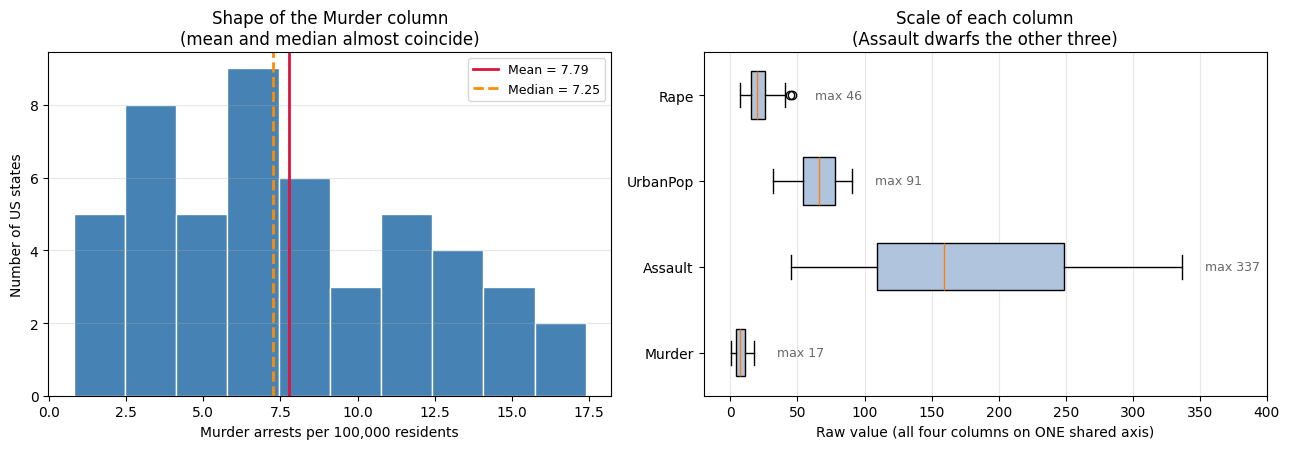

Range of each numeric column (max - min):
  Murder        0.8 ->    17.4   (span   16.6)
  Assault      45.0 ->   337.0   (span  292.0)
  UrbanPop     32.0 ->    91.0   (span   59.0)
  Rape          7.3 ->    46.0   (span   38.7)


In [11]:
# CELL: Draw what the summary table hides - the SHAPE of the data and the SCALE of each column.
# WHY: describe() gives 8 numbers per column. Two very different datasets can produce the same
#      8 numbers. One picture settles in a second what a table of numbers cannot.
import matplotlib.pyplot as plt

num_cols = ['Murder', 'Assault', 'UrbanPop', 'Rape']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))

# --- LEFT: the shape of one column -------------------------------------------------
# WHY a histogram: it shows how many states fall in each value range - the thing a
# mean/median pair can never show.
ax = axes[0]
ax.hist(df['Murder'], bins=10, color='steelblue', edgecolor='white')
mean_v, med_v = df['Murder'].mean(), df['Murder'].median()
ax.axvline(mean_v, color='crimson', linestyle='-', linewidth=2,
           label=f'Mean = {mean_v:.2f}')
ax.axvline(med_v, color='darkorange', linestyle='--', linewidth=2,
           label=f'Median = {med_v:.2f}')
ax.set_xlabel('Murder arrests per 100,000 residents')
ax.set_ylabel('Number of US states')
ax.set_title('Shape of the Murder column\n(mean and median almost coincide)')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

# --- RIGHT: the scale of every column ----------------------------------------------
# WHY boxplots on ONE shared axis: it makes the size mismatch between columns visible.
# This is the reason Example 3 has to scale the features before modelling.
ax = axes[1]
bp = ax.boxplot([df[c] for c in num_cols], vert=False, labels=num_cols,
                patch_artist=True, widths=0.55)
for patch in bp['boxes']:
    patch.set_facecolor('lightsteelblue')
for c in num_cols:
    ax.text(df[c].max() + 17, num_cols.index(c) + 1,
            f'max {df[c].max():.0f}', va='center', fontsize=9, color='dimgray')
ax.set_xlabel('Raw value (all four columns on ONE shared axis)')
ax.set_xlim(-20, 400)
ax.set_title('Scale of each column\n(Assault dwarfs the other three)')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Print the numbers behind the picture so students can check the plot against the data.
print("Range of each numeric column (max - min):")
for c in num_cols:
    print(f"  {c:9s} {df[c].min():7.1f} -> {df[c].max():7.1f}   (span {df[c].max()-df[c].min():6.1f})")

**Read the figure.**

*Left panel — the shape.* The mean (red solid, 7.79) and the median (orange dashed, 7.25) sit
almost on top of each other, and the summary table stopped there. The histogram shows what the
table hid: the Murder column is **spread broadly across the whole 0.8–17.4 range**, with roughly
5–9 states in every bin from 0.8 to about 10 and a thinner tail above it. This is a *wide, flat*
distribution, not a tight bell around 7.79. "Mean ≈ median" ruled out strong skew; it never
promised a peak. That is the concrete meaning of the warning in **⚠️ Where this breaks**: a
histogram settles in one line what a summary table cannot.

*Right panel — the scale.* All four columns are drawn against the **same** horizontal axis.
Assault runs from 45 to 337; Murder is squashed into 0.8–17.4 and its whole box is a sliver near
zero. Nothing is wrong with the data — the columns simply measure different things at different
magnitudes. An algorithm that adds up distances would let Assault decide almost everything. That
is exactly the "features on different scales → NEEDS PREPROCESSING" branch of the decision tree
below, and it is what Example 3 fixes.

## Step 4: Check for Missing Values

**BEFORE**: We don't know if our data has gaps or missing information.

**AFTER**: We'll identify any missing values that could cause problems in our models!

**Why check for missing values?** 
- ML models can't work with missing data
- Missing values indicate data quality issues
- We need to handle them before modeling (fill, drop, or impute)

In [12]:
# Check for missing values
# .isnull() marks missing values as True; .sum() counts them per column
missing_values = df.isnull().sum()
total_missing = missing_values.sum()

print("Missing values per column:")
print(missing_values)

if total_missing == 0:
    print("\n No missing values found! Data is complete.")
else:
    print(f"\n Found {total_missing} missing value(s) total")
    print(" We'll learn how to handle these in Example 2: Data Cleaning")

Missing values per column:
State       0
Murder      0
Assault     0
UrbanPop    0
Rape        0
dtype: int64

 No missing values found! Data is complete.


## Step 5: Check for Duplicates

**BEFORE**: We might have the same row appearing multiple times.

**AFTER**: We'll identify duplicate rows that could skew our analysis!

**Why check for duplicates?**
- Duplicates can bias our models (same data counted twice)
- They waste computational resources
- They indicate data collection issues

In [13]:
# Check for duplicate rows
# .duplicated() marks rows that appear more than once; .sum() counts them
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

if duplicate_count == 0:
    print("\n No duplicate rows found! Each row is unique.")
else:
    print(f"\n Found {duplicate_count} duplicate row(s)")
    print(" We'll learn how to remove these in Example 2: Data Cleaning")
    print("\n Duplicate rows:")
    print(df[df.duplicated()])

Number of duplicate rows: 0

 No duplicate rows found! Each row is unique.


## Step 6: Categorical Data Analysis

**BEFORE**: We see categorical values (like the 50 state names in the State column) but don't know their distribution.

**AFTER**: We'll count how many times each category appears to understand the balance!

**Why analyze categorical data?**
- Shows if categories are balanced or imbalanced
- Helps decide if we need encoding (one-hot, label encoding)
- Reveals data quality issues (unexpected categories)

In [14]:
# Analyze categorical data (State column)
# .value_counts() counts how many times each category appears
state_counts = df['State'].value_counts()

print("State distribution (first 10):")
print(state_counts.head(10))

print("\nInterpretation:")
print(f" - Total distinct states: {len(state_counts)}")

if state_counts.min() == state_counts.max() == 1:
    print(" - Each state appears exactly once (one row per state)")
    print(" - Categories are balanced - perfect for state-level analysis!")
else:
    print(" - Some states appear multiple times")
    print(" - This might indicate duplicate data that needs cleaning")

State distribution (first 10):
State
Alabama           1
Pennsylvania      1
Nevada            1
New Hampshire     1
New Jersey        1
New Mexico        1
New York          1
North Carolina    1
North Dakota      1
Ohio              1
Name: count, dtype: int64

Interpretation:
 - Total distinct states: 50
 - Each state appears exactly once (one row per state)
 - Categories are balanced - perfect for state-level analysis!


## 💬 Discuss

Argue these out before reading on. None has a single correct answer.

1. **This file passes every check we ran** — 50 rows for 50 states, zero missing values, zero
   duplicates. Does "clean" mean "trustworthy"? Name something that could still be badly wrong
   with a table that passes all four checks, and say how you would detect it.

2. **North Dakota reports 0.80 murder arrests per 100,000; Georgia reports 17.40** — a 22× spread.
   Is that a difference in *crime* or a difference in *recording*? What one extra column would
   settle the argument, and what would you do if you could not obtain it?

3. **The columns are rates per 100,000 residents, and there is no population column.** A colleague
   proposes adding Murder + Assault + Rape into a single "crime score" per state and ranking on it.
   Argue for or against — and if against, say what you would build instead.


## Step 7: Data Quality Assessment → Modeling Readiness

**BEFORE**: We've explored the data and found issues, but don't know if it's ready for modeling.

**AFTER**: You'll have a clear framework to assess data quality and determine if your data is ready for machine learning!

**Why this matters**: Building models on poor-quality data leads to:
- **Unreliable predictions** → Models learn from bad patterns
- **Wasted time** → Models fail or perform poorly
- **Wrong conclusions** → Decisions based on flawed data

---

### 🎯 Decision Framework: Is Your Data Ready for Modeling?

**Key Question**: Can I build a machine learning model with this data, or do I need to clean/preprocess first?

#### Decision Tree:

```
Have you completed data exploration?
├─ NO → EXPLORE FIRST (this notebook!)
│   └─ Why? You can't assess quality without exploring
│
└─ YES → Check data quality issues:
    ├─ Missing values > 10%? → NEEDS CLEANING (Example 2)
    │   └─ Why? Too much missing data breaks models
    │
    ├─ Duplicates > 5%? → NEEDS CLEANING (Example 2)
    │   └─ Why? Duplicates bias models (same data counted twice)
    │
    ├─ Outliers that are clearly errors? → NEEDS CLEANING (Example 2)
    │   └─ Why? Errors skew models (e.g., age = 200)
    │
    ├─ Wrong data types? → NEEDS CLEANING (Example 2)
    │   └─ Why? Can't calculate on text (e.g., "25" instead of 25)
    │
    ├─ Features on different scales? → NEEDS PREPROCESSING (Example 3)
    │   └─ Why? Algorithms biased toward larger numbers
    │
    ├─ Categorical features not encoded? → NEEDS PREPROCESSING (Example 3)
    │   └─ Why? ML algorithms need numbers, not text
    │
    └─ All checks passed? → READY FOR MODELING! ✅
        └─ Why? Data is clean, preprocessed, and ready
```

---

### 📊 Data Quality Checklist

Use this checklist to assess your data:

| Quality Aspect | Good | Warning | Critical | Action Needed |
|----------------|------|---------|---------|---------------|
| **Missing Values** | < 5% | 5-10% | > 10% | Clean (Example 2) |
| **Duplicates** | < 1% | 1-5% | > 5% | Remove (Example 2) |
| **Outliers (Errors)** | None | Few | Many | Remove (Example 2) |
| **Data Types** | Correct | Some issues | Many issues | Fix (Example 2) |
| **Feature Scaling** | Similar scales | Different scales | Very different | Preprocess (Example 3) |
| **Categorical Encoding** | Encoded | Some encoded | Not encoded | Preprocess (Example 3) |
| **Sample Size** | > 1000 | 100-1000 | < 100 | May need more data |

**Decision Rule**: If ANY aspect is "Critical", data is **NOT ready** for modeling. Fix issues first!

---

### 📈 Modeling Readiness Levels

#### Level 1: Raw Data (Not Ready) ❌
- **Characteristics**: Just loaded from file, no exploration
- **Issues**: Unknown data quality, unknown structure
- **Action**: Complete this notebook (exploration)

#### Level 2: Explored Data (Partially Ready) ⚠️
- **Characteristics**: Explored structure, found issues
- **Issues**: Missing values, duplicates, outliers, wrong types
- **Action**: Complete Example 2 (cleaning)

#### Level 3: Clean Data (Mostly Ready) ⚠️
- **Characteristics**: Clean, no missing values, correct types
- **Issues**: Features not scaled, categories not encoded
- **Action**: Complete Example 3 (preprocessing)

#### Level 4: Preprocessed Data (Ready!) ✅
- **Characteristics**: Clean, scaled, encoded, split into train/test
- **Issues**: None
- **Action**: Ready for modeling (Example 4+)

---

### 📊 Real-World Examples

#### Example 1: E-commerce Dataset
- **Exploration Findings**: 15% missing prices, 3% duplicates, prices range $10-$10,000
- **Quality Assessment**: ❌ NOT READY
- **Issues**: Too many missing values, features need scaling
- **Action Plan**: 
  1. Clean missing values (Example 2)
  2. Scale prices (Example 3)
  3. Then model (Example 4)

#### Example 2: Medical Dataset
- **Exploration Findings**: 2% missing ages, no duplicates, age range 0-100
- **Quality Assessment**: ⚠️ PARTIALLY READY
- **Issues**: Small missing values (can remove), but need to check other features
- **Action Plan**:
  1. Remove missing values (Example 2)
  2. Check if scaling needed (Example 3)
  3. Then model (Example 4)

#### Example 3: Customer Dataset
- **Exploration Findings**: No missing values, no duplicates, all features scaled, categories encoded
- **Quality Assessment**: ✅ READY
- **Issues**: None
- **Action Plan**: Ready to build models (Example 4)

---

### ✅ Key Takeaways

1. **Always explore first** - You can't assess quality without exploration
2. **Check all quality aspects** - Missing values, duplicates, outliers, types, scaling, encoding
3. **Use the checklist** - Systematic assessment prevents missing issues
4. **Fix critical issues first** - Don't model on bad data
5. **Understand readiness levels** - Know where your data stands
6. **Document findings** - Write down what you found and what needs fixing

---

### 🎓 Practice Assessment

**Scenario**: You've explored a dataset and found:
- 8% missing values in "income" column
- 2% duplicate rows
- Age ranges from 18 to 65 (reasonable)
- Salary ranges from $30,000 to $200,000
- Department column has categories: "IT", "HR", "Finance"

**Your task**: Assess data quality and determine modeling readiness!

**Answer**:
1. **Missing values (8%)**: ⚠️ WARNING - Should clean (Example 2)
2. **Duplicates (2%)**: ✅ GOOD - Can remove (Example 2)
3. **Age range**: ✅ GOOD - Reasonable range
4. **Salary range**: ⚠️ WARNING - Different scale from age, needs scaling (Example 3)
5. **Department**: ⚠️ WARNING - Categorical, needs encoding (Example 3)
6. **Overall Assessment**: ⚠️ PARTIALLY READY
7. **Action Plan**: 
   - Clean missing values and duplicates (Example 2)
   - Scale salary and encode department (Example 3)
   - Then ready for modeling (Example 4)

---

**Connection to Next Steps**: 
- 📓 **Example 2: Data Cleaning** - Fixes the quality issues we found
- 📓 **Example 3: Data Preprocessing** - Prepares clean data for modeling
- 📓 **Example 4: Linear Regression** - Builds models on ready data!

## ❓ Common Student Questions

**Q: Why do we need to explore data before building models?**
- **Answer**: You can't build good models on bad data! Exploration helps you:
  - Find problems early (missing values, duplicates, outliers)
  - Understand data structure (what columns mean, what types you have)
  - Make informed decisions (what preprocessing is needed)
  - Save time later (catch issues before they break your models)

**Q: What's the difference between .head() and .tail()?**
- **Answer**: 
  - `.head(n)`: Shows first n rows (default: 5)
  - `.tail(n)`: Shows last n rows (default: 5)
  - **Why both?** Check beginning AND end to see if data is consistent

**Q: Why check for missing values? Can't I just ignore them?**
- **Answer**: **NO!** ML models can't work with missing data. You MUST handle them:
  - **Option 1**: Remove rows with missing values (if few missing)
  - **Option 2**: Fill missing values (mean, median, mode, or prediction)
  - **Option 3**: Use algorithms that handle missing values (advanced)
  - **We'll learn this in Example 2: Data Cleaning**

**Q: What's the difference between mean and median?**
- **Answer**:
  - **Mean**: Average (sum of all values / count) - affected by outliers
  - **Median**: Middle value (50th percentile) - NOT affected by outliers
  - **Example**: [1, 2, 3, 4, 100] → Mean = 22, Median = 3
  - **When to use**: Use median when you have outliers (extreme values)

**Q: Why check for duplicates?**
- **Answer**: Duplicates can bias your models:
  - Same data counted twice → model learns from same pattern twice
  - Wastes computational resources
  - Indicates data collection issues
  - **Solution**: Remove duplicates (we'll learn in Example 2)

**Q: What if my dataset has different structure (different columns, types)?**
- **Answer**: **That's normal!** Every dataset is different. The key is:
  - **Understand YOUR data structure** (rows, columns, types)
  - **Apply the same exploration steps** (shape, types, missing values, duplicates)
  - **Adapt to your specific data** (different columns need different analysis)
  - **Focus on structure, not domain** (CS students work with many domains!)

**Q: How do I know if my data is ready for modeling?**
- **Answer**: Use the Data Quality Checklist (Step 7 above):
  - ✅ No missing values (or < 5%)
  - ✅ No duplicates (or < 1%)
  - ✅ Correct data types
  - ✅ Features scaled (if needed)
  - ✅ Categories encoded (if needed)
  - **If all checks pass → Ready for modeling!**

**Q: What's the difference between .info() and .describe()?**
- **Answer**:
  - **`.info()`**: Shows data types, non-null counts, memory usage (structure)
  - **`.describe()`**: Shows statistics (mean, std, min, max) for numeric columns (summary)
  - **Use both**: `.info()` for structure, `.describe()` for statistics

---

## 🎯 Summary: What We Learned

**BEFORE this notebook**: We had raw data files we couldn't use.

**AFTER this notebook**: We can:
- ✅ Load data from CSV files
- ✅ Inspect data structure and types
- ✅ Calculate statistical summaries
- ✅ Identify data quality issues (missing values, duplicates)
- ✅ Analyze both numerical and categorical data

**Next Steps**: 
- 📓 Example 2: Data Cleaning (fix the issues we found)
- 📓 Example 3: Data Preprocessing (prepare data for modeling)
- 📓 Example 4: Linear Regression (build our first model!)

---

## ✅ Example 1 Complete!

You've learned the foundation of data science: **exploration before modeling**!

**Key Takeaway**: Always explore your data first. You can't build good models on bad data!

## ⚠️ Where this breaks

**Exploration tells you what is inside the file. It cannot tell you the file is the right one.**

- **The assumption that must hold:** the rows are the population you actually care about. Here they
  are 50 US states, one year, **arrests** — not crimes committed, not convictions, not people. Any
  sentence in your report of the form "crime in X is higher than in Y" is already beyond what this
  table supports.
- **`describe()` hides shape.** Fifty states at 7.79 and twenty-five states at 0.8 paired with
  twenty-five at 14.8 both give mean ≈ 7.79. The mean (7.79) and median (7.25) being close is
  weak evidence of a single hump, not proof — a histogram settles in one line what a summary table
  cannot.
- **"No missing values" is not the same as "nothing missing".** A state that reported nothing may
  appear here as 0.0 rather than as NaN, and no `isnull()` check will ever find it.
- **The cheaper alternative:** for a 50-row table, `df.info()` + `df.describe()` + one
  `value_counts()` on the key column is the whole job. Reach for a full automated profiling report
  only when the table is too large to look at — on small data it costs more time than it saves.


## 📚 References

1. Tukey, J. W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
2. Pedregosa, F., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830. <https://arxiv.org/abs/1201.0490>
3. Gebru, T., Morgenstern, J., Vecchione, B., Vaughan, J. W., Wallach, H., Daumé III, H., & Crawford, K. (2021). *Datasheets for Datasets*. Communications of the ACM, 64(12). <https://arxiv.org/abs/1803.09010>
4. James, G., Witten, D., Hastie, T., & Tibshirani, R. (2021). *An Introduction to Statistical Learning* (2nd ed.), Chapter 2. Springer.
5. Papastergios, V., Ehrlinger, L., & Gounaris, A. (2025). *Unfolding Data Quality Dimensions in Practice: A Survey*. <https://arxiv.org/abs/2507.17507>
6. Berti-Equille, L. (2026). *Data Quality Profiling at Scale with Progressive Sampling: A Benchmark for Data-Centric AI Pipelines*. <https://arxiv.org/abs/2607.25356>
